## Loading the Data

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from termcolor import colored

In [22]:
path= 'credit_risk_dataset.csv'
df= pd.read_csv(path)

## EDA

In [23]:
df.shape

(32581, 12)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [25]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [26]:
df.dtypes.value_counts()

int64      5
object     4
float64    3
Name: count, dtype: int64

In [27]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [28]:
# questions to answer
# Are (Young / low income) people more likely to default.
# do bad loan_grades significantly affect the default status.
# are higher loan amount / interest rates increase the default probability.
# do people with stable jobs default less.

In [29]:
# our data studies the credit card default status of some unknown bank in an unknown location.
# no id or name in each record, some people could have taken many loans at the same time.

In [31]:
print('duplicated rows:',colored(df.duplicated().sum(),'yellow')) # 165 duplicated rows
df.drop_duplicates(inplace= True)

duplicated rows: 165


In [34]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [37]:
# segmenting the records based on unique identifier (a person)
df.duplicated(subset= ['person_age', 'person_income', 'person_home_ownership','person_emp_length',
                       'cb_person_default_on_file', 'cb_person_cred_hist_length'], keep= False).sum()

5835

In [45]:
flag_identifier_cols= ['person_age', 'person_income', 'person_home_ownership','person_emp_length',
                       'cb_person_default_on_file', 'cb_person_cred_hist_length']
df['count']= df.groupby(flag_identifier_cols, dropna= False)['person_age'].transform('count')

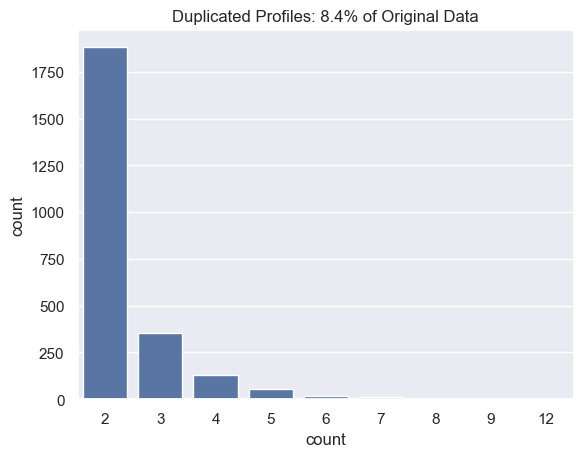

In [81]:
mask= df.duplicated(subset= flag_identifier_cols)
new_mask= df[~mask]['count'] > 1
percentage = round((len(df[~mask][new_mask]) / len(df[~mask])) * 100, 1)
plt.figure()
sns.countplot(data= df[~mask][new_mask], x= 'count')
plt.title(f'Duplicated Profiles: {percentage}% of Original Data')
plt.show()
# it appears around 8% of the records belong to people that took more than
# one loan at the same time, with around 1700 of them taking two loans at once,
# importance to keep in mind.

## Feature Engineering

## Preprocessing

## Model Selection

## Model Tunning